In [8]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

pd.set_option('display.max_columns', None)

## First cluster MEs

In [9]:
ctype_abundance_df = pd.read_csv("data/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)

In [10]:
ctype_abundance_df.head()

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Sample,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SRR21354976,-0.034837,-0.026764,-0.036847,-0.035096,-0.042860,-0.033260,-0.030904,0.009896,0.072879,-0.053250,-0.036847,-0.062070,-0.066005,-0.065431,-0.038439,-0.059464,-0.035096,-0.035042,-0.035096,-0.034401,-0.067606,-0.049849,-0.033271,-0.033260,-0.033260,-0.041189,-0.041452,-0.041189,0.019323,0.009954
SRR21354977,-0.091338,-0.093546,-0.094851,-0.088086,-0.077668,-0.091549,-0.093771,-0.075887,-0.053358,-0.055988,-0.094851,-0.071953,-0.077210,-0.076199,-0.067267,-0.051264,-0.088086,-0.046715,-0.088086,-0.090855,-0.085693,-0.074772,-0.088341,-0.091549,-0.091549,-0.068879,-0.078490,-0.068879,-0.023355,-0.078580
SRR21354978,0.076666,0.068365,0.066358,0.074225,0.060270,0.076871,0.071862,0.078696,0.145524,-0.021463,0.066358,0.089408,0.106774,0.116572,0.051971,0.059705,0.074225,0.007850,0.074225,0.076487,0.068675,0.053528,0.076262,0.076871,0.076871,0.050955,0.061999,0.050955,0.035556,0.088910
SRR21354980,-0.051619,-0.046899,-0.053411,-0.050793,-0.051459,-0.050920,-0.048845,-0.024877,0.012330,-0.057313,-0.053411,-0.061819,-0.070584,-0.068863,-0.046487,-0.060932,-0.050793,-0.038222,-0.050793,-0.051662,-0.066989,-0.061735,-0.049873,-0.050920,-0.050920,-0.047986,-0.049071,-0.047986,-0.031485,-0.020829
SRR21354981,0.072638,0.069667,0.060739,0.068894,0.042498,0.075792,0.093496,0.128616,0.176836,0.003374,0.060739,0.050792,0.059751,0.059943,0.038385,0.000367,0.068894,0.001463,0.068894,0.071449,0.040493,0.029516,0.072346,0.075792,0.075792,0.036684,0.046002,0.036684,0.045061,0.114004


In [11]:
abund_corr_mat = ctype_abundance_df.corr()

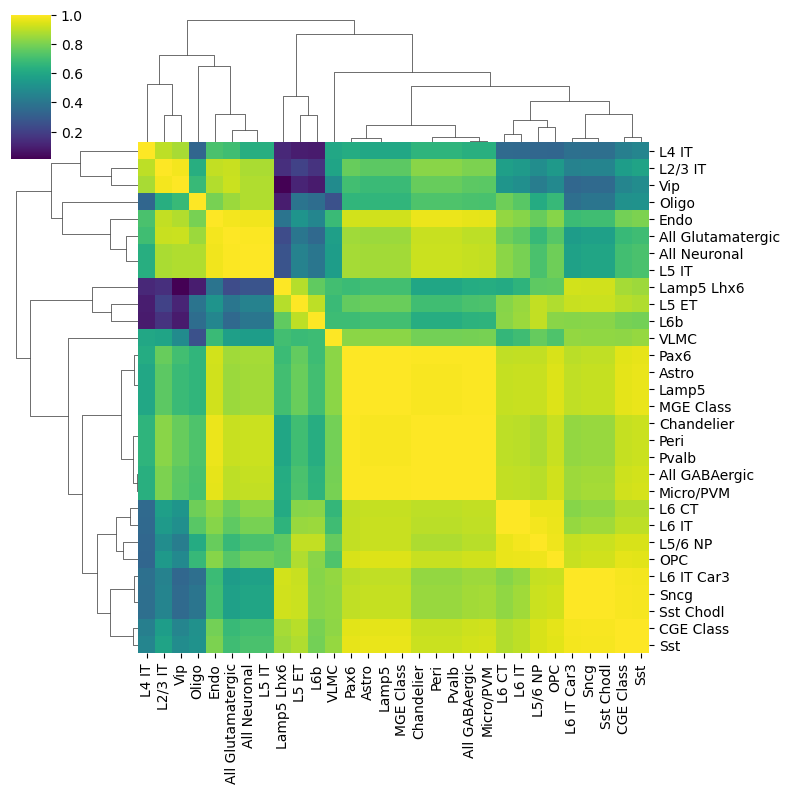

In [12]:
sns.clustermap(abund_corr_mat, cmap='viridis', figsize=(8, 8))

## Cluster by gene expression corr

In [13]:
expr_corr_df = pd.read_csv("data/corrs/hahn_2023_cortex_STAR_counts_TMMF_All_130_outliers_removed_44764genes_cleaned_mergeParam0.93_minSignum0.88_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)

In [14]:
expr_corr_mat = expr_corr_df.corr()

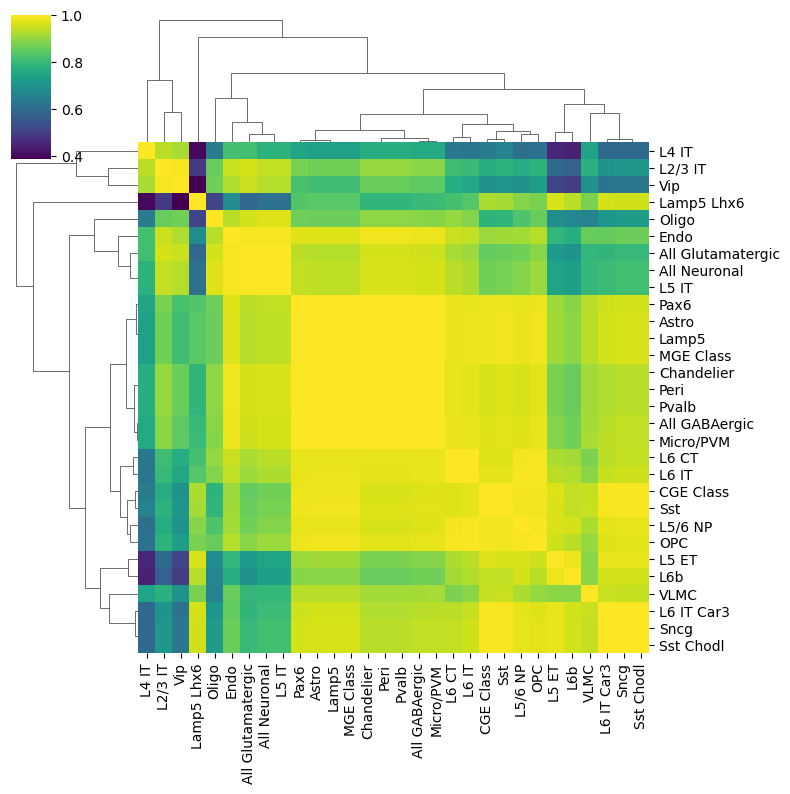

In [15]:
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(8, 8))

In [16]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Rbfox3,0.909501,0.989370,0.991697,0.861142,0.705671,0.919192,0.974236,0.880429,0.641337,0.438218,0.991697,0.699304,0.803976,0.776012,0.582794,0.377948,0.861142,0.283933,0.861142,0.907375,0.771250,0.851209,0.867899,0.919192,0.919192,0.600037,0.718592,0.600037,0.558033,0.878923
Acsl6,0.941217,0.985904,0.989930,0.900255,0.758419,0.949083,0.985850,0.878069,0.656710,0.504925,0.989930,0.760115,0.845723,0.823799,0.644061,0.455217,0.900255,0.347620,0.900255,0.939557,0.817544,0.840088,0.906437,0.949083,0.949083,0.660178,0.771216,0.660178,0.620594,0.870509
Snap25,0.847827,0.980848,0.987031,0.787579,0.610396,0.859953,0.941674,0.848698,0.579390,0.360529,0.987031,0.638290,0.770571,0.735921,0.472502,0.316679,0.787579,0.158263,0.787579,0.845107,0.713578,0.896730,0.794736,0.859953,0.859953,0.493135,0.623062,0.493135,0.456838,0.870341
Syt1,0.937515,0.984845,0.986808,0.895690,0.749077,0.945828,0.985540,0.883756,0.673629,0.493615,0.986808,0.757598,0.849848,0.828547,0.634159,0.454701,0.895690,0.332742,0.895690,0.935561,0.809974,0.853135,0.902152,0.945828,0.945828,0.649957,0.762133,0.649957,0.606442,0.874365
Kcnc1,0.847470,0.977730,0.980531,0.788179,0.612817,0.859601,0.938899,0.859512,0.599144,0.362977,0.980531,0.629712,0.757279,0.722362,0.477032,0.296341,0.788179,0.168072,0.788179,0.844936,0.703210,0.879608,0.795771,0.859601,0.859601,0.496920,0.626316,0.496920,0.460160,0.875845
Cck,0.891943,0.965827,0.975846,0.846009,0.703725,0.900025,0.951677,0.824330,0.564619,0.448745,0.975846,0.697667,0.810097,0.782885,0.580853,0.377165,0.846009,0.297890,0.846009,0.889400,0.785514,0.865026,0.850678,0.900025,0.900025,0.599402,0.712613,0.599402,0.506063,0.833090
Mafb,0.918855,0.976843,0.975466,0.875569,0.728250,0.927820,0.972376,0.886723,0.665075,0.472925,0.975466,0.714940,0.807066,0.782434,0.612702,0.395340,0.875569,0.321928,0.875569,0.917083,0.778227,0.832244,0.882621,0.927820,0.927820,0.628295,0.742063,0.628295,0.586071,0.874140
Fn3krp,0.869648,0.970456,0.973576,0.817459,0.656555,0.880168,0.946030,0.853294,0.593076,0.408657,0.973576,0.662473,0.779040,0.747099,0.528436,0.337610,0.817459,0.231106,0.817459,0.867207,0.737123,0.870897,0.824030,0.880168,0.880168,0.547082,0.668906,0.547082,0.495472,0.858047
Gpsm2,0.910879,0.964933,0.969866,0.868592,0.726418,0.919020,0.960664,0.856853,0.633433,0.479609,0.969866,0.733932,0.828622,0.806618,0.610885,0.424494,0.868592,0.318129,0.868592,0.909031,0.794010,0.839312,0.874634,0.919020,0.919020,0.627404,0.738730,0.627404,0.571605,0.854627


In [17]:
expr_corr_df.sort_values("Astro", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ndrg2,0.990094,0.858517,0.868174,0.992833,0.944366,0.987229,0.930020,0.764312,0.621050,0.755643,0.868174,0.913157,0.907887,0.910593,0.886927,0.694879,0.992833,0.670127,0.992833,0.990512,0.934699,0.660538,0.993317,0.987229,0.987229,0.894904,0.952484,0.894904,0.821352,0.700304
Bcan,0.986993,0.851448,0.862107,0.991187,0.947847,0.983584,0.923008,0.754296,0.604968,0.759443,0.862107,0.908698,0.902125,0.904028,0.892900,0.698309,0.991187,0.683218,0.991187,0.987545,0.933796,0.648687,0.991231,0.983584,0.983584,0.900517,0.955237,0.900517,0.831921,0.686428
Gad2,0.972785,0.813881,0.830937,0.984828,0.968916,0.966170,0.890431,0.688127,0.510706,0.803362,0.830937,0.906963,0.898039,0.900354,0.919889,0.690893,0.984828,0.746843,0.984828,0.973320,0.954937,0.639692,0.981656,0.966170,0.966170,0.928242,0.971767,0.928242,0.787585,0.613197
Pla2g7,0.976062,0.826106,0.845947,0.984398,0.957610,0.970192,0.898834,0.695449,0.533317,0.803542,0.845947,0.927344,0.921093,0.922980,0.905292,0.726286,0.984398,0.712193,0.984398,0.976622,0.955650,0.668686,0.981973,0.970192,0.970192,0.914195,0.961734,0.914195,0.801536,0.632848
Bsg,0.987452,0.893845,0.904548,0.980941,0.913875,0.986343,0.946723,0.781166,0.615823,0.715023,0.904548,0.885388,0.906165,0.902454,0.842791,0.649912,0.980941,0.610522,0.980941,0.987391,0.918732,0.718571,0.981755,0.986343,0.986343,0.853021,0.921519,0.853021,0.784308,0.729490
Cx3cr1,0.970613,0.820019,0.832917,0.979866,0.953151,0.965288,0.893988,0.710894,0.564904,0.762605,0.832917,0.893724,0.887823,0.891157,0.903745,0.688685,0.979866,0.716527,0.979866,0.971148,0.933868,0.633319,0.978241,0.965288,0.965288,0.910817,0.957449,0.910817,0.810576,0.640912
Erbb4,0.963848,0.789378,0.795816,0.978544,0.956111,0.958802,0.881372,0.725330,0.605140,0.786035,0.795816,0.910844,0.878338,0.887514,0.918249,0.719438,0.978544,0.733107,0.978544,0.964818,0.922311,0.570269,0.978485,0.958802,0.958802,0.922678,0.963934,0.922678,0.844466,0.640638
Fgfr3,0.977144,0.858903,0.872200,0.977604,0.930732,0.973881,0.919204,0.743265,0.569785,0.752811,0.872200,0.896334,0.898579,0.895928,0.869182,0.672482,0.977604,0.659165,0.977604,0.977508,0.930242,0.675427,0.976993,0.973881,0.973881,0.878657,0.937315,0.878657,0.794123,0.680688
Map2,0.957443,0.767118,0.787518,0.977129,0.980468,0.948535,0.855513,0.646287,0.496261,0.836815,0.787518,0.933614,0.910382,0.917646,0.944725,0.752179,0.977129,0.786445,0.977129,0.958269,0.962232,0.601873,0.973139,0.948535,0.948535,0.951293,0.982653,0.951293,0.791815,0.567976


In [18]:
expr_corr_df.sort_values("VLMC", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ptgds,0.727609,0.489842,0.478558,0.765044,0.779804,0.722034,0.610986,0.528335,0.570254,0.642543,0.478558,0.705774,0.591903,0.621633,0.798816,0.653528,0.765044,0.681856,0.765044,0.731498,0.655477,0.171316,0.766976,0.722034,0.722034,0.790423,0.789133,0.790423,0.984926,0.422758
Aebp1,0.703171,0.469182,0.454300,0.740204,0.752173,0.698550,0.592361,0.535294,0.585107,0.617242,0.454300,0.681110,0.563828,0.594154,0.773468,0.634809,0.740204,0.656465,0.740204,0.707169,0.626963,0.156056,0.743213,0.698550,0.698550,0.764087,0.763019,0.764087,0.976649,0.424759
Efemp1,0.801434,0.585094,0.585616,0.830972,0.831530,0.795745,0.693452,0.569331,0.549698,0.702692,0.585616,0.786349,0.701512,0.723325,0.830857,0.714252,0.830972,0.683163,0.830972,0.804921,0.745738,0.327704,0.831578,0.795745,0.795745,0.827137,0.839787,0.827137,0.974824,0.473032
Slc6a20a,0.722182,0.475289,0.473441,0.761500,0.784635,0.714978,0.596537,0.484074,0.505169,0.676180,0.473441,0.746714,0.632400,0.663009,0.803561,0.723180,0.761500,0.685078,0.761500,0.726267,0.683769,0.187603,0.761841,0.714978,0.714978,0.796805,0.792758,0.796805,0.972938,0.380629
Fn1,0.802351,0.575885,0.578500,0.833368,0.838721,0.796292,0.691530,0.563567,0.548194,0.699267,0.578500,0.807790,0.711883,0.738574,0.840458,0.744419,0.833368,0.690969,0.833368,0.805743,0.758882,0.290818,0.834350,0.796292,0.796292,0.836582,0.847710,0.836582,0.971867,0.471717
Slc13a3,0.817103,0.596451,0.600766,0.847104,0.853459,0.810860,0.707353,0.568353,0.522585,0.714695,0.600766,0.808446,0.722458,0.744763,0.851731,0.731337,0.847104,0.705981,0.847104,0.820400,0.778172,0.318947,0.847253,0.810860,0.810860,0.848934,0.860852,0.848934,0.971807,0.474845
Anxa2,0.756977,0.547547,0.528498,0.787311,0.784051,0.753577,0.657091,0.603108,0.645113,0.606667,0.528498,0.676710,0.581860,0.606421,0.792683,0.575968,0.787311,0.663519,0.787311,0.760531,0.646871,0.219130,0.791089,0.753577,0.753577,0.784369,0.794983,0.784369,0.971778,0.498919
Serping1,0.709312,0.491817,0.479806,0.742177,0.744465,0.705223,0.603638,0.532813,0.573228,0.604444,0.479806,0.676331,0.575182,0.602809,0.757444,0.625900,0.742177,0.629692,0.742177,0.713339,0.625546,0.193048,0.744823,0.705223,0.705223,0.749459,0.754514,0.749459,0.971611,0.431333
Bmp7,0.809592,0.534719,0.537188,0.854366,0.895783,0.799418,0.666315,0.524376,0.518976,0.775207,0.537188,0.822551,0.711365,0.739921,0.914650,0.758414,0.854366,0.811777,0.854366,0.813104,0.787945,0.251722,0.852425,0.799418,0.799418,0.908810,0.901275,0.908810,0.970348,0.408745


In [19]:
expr_corr_df.sort_values("Endo", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Slc1a2,0.958716,0.968641,0.967803,0.925861,0.794564,0.966058,0.991419,0.893609,0.694186,0.534652,0.967803,0.785445,0.845459,0.830467,0.692909,0.495470,0.925861,0.403700,0.925861,0.957380,0.832638,0.782345,0.932672,0.966058,0.966058,0.705871,0.808659,0.705871,0.687510,0.869684
Acsl6,0.941217,0.985904,0.989930,0.900255,0.758419,0.949083,0.985850,0.878069,0.656710,0.504925,0.989930,0.760115,0.845723,0.823799,0.644061,0.455217,0.900255,0.347620,0.900255,0.939557,0.817544,0.840088,0.906437,0.949083,0.949083,0.660178,0.771216,0.660178,0.620594,0.870509
Syt1,0.937515,0.984845,0.986808,0.895690,0.749077,0.945828,0.985540,0.883756,0.673629,0.493615,0.986808,0.757598,0.849848,0.828547,0.634159,0.454701,0.895690,0.332742,0.895690,0.935561,0.809974,0.853135,0.902152,0.945828,0.945828,0.649957,0.762133,0.649957,0.606442,0.874365
Glul,0.973530,0.955907,0.959913,0.947229,0.833129,0.978100,0.981500,0.859596,0.675272,0.604349,0.959913,0.824293,0.877107,0.864531,0.738434,0.549943,0.947229,0.461526,0.947229,0.972806,0.861294,0.788098,0.952210,0.978100,0.978100,0.751104,0.845344,0.751104,0.722445,0.831192
Aldh1l1,0.967019,0.946416,0.947388,0.941246,0.825886,0.972139,0.976979,0.864247,0.691964,0.579744,0.947388,0.817180,0.859614,0.849923,0.733890,0.544586,0.941246,0.455016,0.941246,0.966284,0.850030,0.744590,0.947034,0.972139,0.972139,0.745627,0.839244,0.745627,0.734517,0.837012
Rbfox3,0.909501,0.989370,0.991697,0.861142,0.705671,0.919192,0.974236,0.880429,0.641337,0.438218,0.991697,0.699304,0.803976,0.776012,0.582794,0.377948,0.861142,0.283933,0.861142,0.907375,0.771250,0.851209,0.867899,0.919192,0.919192,0.600037,0.718592,0.600037,0.558033,0.878923
Mafb,0.918855,0.976843,0.975466,0.875569,0.728250,0.927820,0.972376,0.886723,0.665075,0.472925,0.975466,0.714940,0.807066,0.782434,0.612702,0.395340,0.875569,0.321928,0.875569,0.917083,0.778227,0.832244,0.882621,0.927820,0.927820,0.628295,0.742063,0.628295,0.586071,0.874140
Maf,0.937196,0.949196,0.941370,0.905787,0.774926,0.945301,0.970841,0.893858,0.702019,0.514225,0.941370,0.730586,0.783550,0.767442,0.677240,0.427058,0.905787,0.402434,0.905787,0.936409,0.786378,0.736784,0.913188,0.945301,0.945301,0.688572,0.789388,0.688572,0.716067,0.860601
Mpc1-ps,0.936963,0.955284,0.955649,0.902813,0.769899,0.943989,0.967375,0.863262,0.675577,0.527156,0.955649,0.765897,0.833671,0.816307,0.667066,0.484243,0.902813,0.380110,0.902813,0.935738,0.809283,0.789470,0.908711,0.943989,0.943989,0.680831,0.782957,0.680831,0.677027,0.842517


In [20]:
expr_corr_df.sort_values("All Glutamatergic", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Rbfox3,0.909501,0.989370,0.991697,0.861142,0.705671,0.919192,0.974236,0.880429,0.641337,0.438218,0.991697,0.699304,0.803976,0.776012,0.582794,0.377948,0.861142,0.283933,0.861142,0.907375,0.771250,0.851209,0.867899,0.919192,0.919192,0.600037,0.718592,0.600037,0.558033,0.878923
Acsl6,0.941217,0.985904,0.989930,0.900255,0.758419,0.949083,0.985850,0.878069,0.656710,0.504925,0.989930,0.760115,0.845723,0.823799,0.644061,0.455217,0.900255,0.347620,0.900255,0.939557,0.817544,0.840088,0.906437,0.949083,0.949083,0.660178,0.771216,0.660178,0.620594,0.870509
Syt1,0.937515,0.984845,0.986808,0.895690,0.749077,0.945828,0.985540,0.883756,0.673629,0.493615,0.986808,0.757598,0.849848,0.828547,0.634159,0.454701,0.895690,0.332742,0.895690,0.935561,0.809974,0.853135,0.902152,0.945828,0.945828,0.649957,0.762133,0.649957,0.606442,0.874365
Snap25,0.847827,0.980848,0.987031,0.787579,0.610396,0.859953,0.941674,0.848698,0.579390,0.360529,0.987031,0.638290,0.770571,0.735921,0.472502,0.316679,0.787579,0.158263,0.787579,0.845107,0.713578,0.896730,0.794736,0.859953,0.859953,0.493135,0.623062,0.493135,0.456838,0.870341
Kcnc1,0.847470,0.977730,0.980531,0.788179,0.612817,0.859601,0.938899,0.859512,0.599144,0.362977,0.980531,0.629712,0.757279,0.722362,0.477032,0.296341,0.788179,0.168072,0.788179,0.844936,0.703210,0.879608,0.795771,0.859601,0.859601,0.496920,0.626316,0.496920,0.460160,0.875845
Mafb,0.918855,0.976843,0.975466,0.875569,0.728250,0.927820,0.972376,0.886723,0.665075,0.472925,0.975466,0.714940,0.807066,0.782434,0.612702,0.395340,0.875569,0.321928,0.875569,0.917083,0.778227,0.832244,0.882621,0.927820,0.927820,0.628295,0.742063,0.628295,0.586071,0.874140
Fn3krp,0.869648,0.970456,0.973576,0.817459,0.656555,0.880168,0.946030,0.853294,0.593076,0.408657,0.973576,0.662473,0.779040,0.747099,0.528436,0.337610,0.817459,0.231106,0.817459,0.867207,0.737123,0.870897,0.824030,0.880168,0.880168,0.547082,0.668906,0.547082,0.495472,0.858047
Nrgn,0.817655,0.970038,0.964101,0.753517,0.566153,0.831970,0.926183,0.879579,0.648283,0.277142,0.964101,0.561168,0.692429,0.658739,0.428792,0.213093,0.753517,0.117167,0.753517,0.814531,0.645848,0.838389,0.763228,0.831970,0.831970,0.447405,0.580927,0.447405,0.426578,0.907037
Esam,0.905563,0.969494,0.966466,0.860681,0.705574,0.915918,0.966598,0.890414,0.683613,0.445246,0.966466,0.701940,0.789418,0.767832,0.590776,0.388493,0.860681,0.289028,0.860681,0.903877,0.753939,0.799680,0.869056,0.915918,0.915918,0.605357,0.720221,0.605357,0.608411,0.886410


In [21]:
expr_corr_df.sort_values("All GABAergic", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ndrg2,0.990094,0.858517,0.868174,0.992833,0.944366,0.987229,0.930020,0.764312,0.621050,0.755643,0.868174,0.913157,0.907887,0.910593,0.886927,0.694879,0.992833,0.670127,0.992833,0.990512,0.934699,0.660538,0.993317,0.987229,0.987229,0.894904,0.952484,0.894904,0.821352,0.700304
Bsg,0.987452,0.893845,0.904548,0.980941,0.913875,0.986343,0.946723,0.781166,0.615823,0.715023,0.904548,0.885388,0.906165,0.902454,0.842791,0.649912,0.980941,0.610522,0.980941,0.987391,0.918732,0.718571,0.981755,0.986343,0.986343,0.853021,0.921519,0.853021,0.784308,0.729490
Bcan,0.986993,0.851448,0.862107,0.991187,0.947847,0.983584,0.923008,0.754296,0.604968,0.759443,0.862107,0.908698,0.902125,0.904028,0.892900,0.698309,0.991187,0.683218,0.991187,0.987545,0.933796,0.648687,0.991231,0.983584,0.983584,0.900517,0.955237,0.900517,0.831921,0.686428
Hexb,0.978760,0.907101,0.921879,0.966876,0.891880,0.978494,0.950251,0.776462,0.576781,0.688109,0.921879,0.870643,0.906765,0.898299,0.811707,0.627420,0.966876,0.571380,0.966876,0.978517,0.916046,0.759123,0.967558,0.978494,0.978494,0.823688,0.898758,0.823688,0.747802,0.731928
Fgfr3,0.977144,0.858903,0.872200,0.977604,0.930732,0.973881,0.919204,0.743265,0.569785,0.752811,0.872200,0.896334,0.898579,0.895928,0.869182,0.672482,0.977604,0.659165,0.977604,0.977508,0.930242,0.675427,0.976993,0.973881,0.973881,0.878657,0.937315,0.878657,0.794123,0.680688
Pla2g7,0.976062,0.826106,0.845947,0.984398,0.957610,0.970192,0.898834,0.695449,0.533317,0.803542,0.845947,0.927344,0.921093,0.922980,0.905292,0.726286,0.984398,0.712193,0.984398,0.976622,0.955650,0.668686,0.981973,0.970192,0.970192,0.914195,0.961734,0.914195,0.801536,0.632848
Snhg14,0.975970,0.889906,0.890378,0.967416,0.889785,0.977406,0.952794,0.833688,0.671591,0.679613,0.890378,0.859310,0.869209,0.867698,0.819793,0.602587,0.967416,0.580760,0.967416,0.975678,0.889930,0.675033,0.971349,0.977406,0.977406,0.828520,0.901803,0.828520,0.766318,0.774212
Aldoc,0.974720,0.859081,0.866161,0.974049,0.915083,0.973286,0.923429,0.770466,0.631486,0.720055,0.866161,0.876125,0.874912,0.875677,0.855142,0.662050,0.974049,0.632101,0.974049,0.975442,0.897522,0.651245,0.975523,0.973286,0.973286,0.862737,0.924162,0.862737,0.839158,0.708272
Scrib,0.973567,0.850574,0.860005,0.975471,0.928944,0.970649,0.916407,0.754305,0.595261,0.748209,0.860005,0.886712,0.893150,0.892266,0.870508,0.657159,0.975471,0.664588,0.975471,0.973951,0.916926,0.678755,0.975703,0.970649,0.970649,0.878571,0.935984,0.878571,0.783352,0.687903


In [22]:
expr_corr_df.sort_values("Oligo", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cnp,0.764524,0.867107,0.898516,0.713252,0.573308,0.770694,0.826440,0.651260,0.376631,0.451006,0.898516,0.674549,0.826431,0.791886,0.442998,0.425610,0.713252,0.164420,0.713252,0.761860,0.725327,0.989106,0.714152,0.770694,0.770694,0.466809,0.577664,0.466809,0.323684,0.687917
Mag,0.626625,0.787607,0.823328,0.564563,0.412239,0.634832,0.720120,0.555813,0.257948,0.326973,0.823328,0.541705,0.722304,0.680015,0.273132,0.302748,0.564563,0.005148,0.564563,0.623271,0.599108,0.988245,0.565460,0.634832,0.634832,0.299456,0.415092,0.299456,0.144179,0.617821
Gjc3,0.737081,0.860172,0.891404,0.681724,0.534730,0.744574,0.813686,0.645325,0.346053,0.412573,0.891404,0.635614,0.794353,0.756037,0.399930,0.377732,0.681724,0.121778,0.681724,0.734107,0.696564,0.988007,0.683047,0.744574,0.744574,0.424545,0.539231,0.424545,0.277493,0.686548
Plp1,0.661601,0.785792,0.825632,0.607633,0.472858,0.667481,0.733332,0.545183,0.250489,0.397418,0.825632,0.603300,0.768138,0.729969,0.341956,0.380003,0.607633,0.082188,0.607633,0.658632,0.656195,0.986239,0.607110,0.667481,0.667481,0.367592,0.474489,0.367592,0.198107,0.599518
Fa2h,0.691273,0.804899,0.842229,0.639353,0.505274,0.697122,0.758062,0.572370,0.284987,0.422038,0.842229,0.626037,0.786490,0.749698,0.375628,0.396473,0.639353,0.112664,0.639353,0.688469,0.677374,0.986082,0.639082,0.697122,0.697122,0.400505,0.507287,0.400505,0.239000,0.618723
Mbp,0.649766,0.780649,0.818673,0.594649,0.455928,0.656135,0.724154,0.543965,0.253379,0.389206,0.818673,0.586585,0.752001,0.712388,0.324422,0.364223,0.594649,0.063082,0.594649,0.646926,0.634537,0.985909,0.594402,0.656135,0.656135,0.349804,0.457969,0.349804,0.199931,0.596569
Mog,0.636322,0.795776,0.829501,0.574156,0.419193,0.644866,0.729972,0.571649,0.287511,0.319702,0.829501,0.548858,0.727375,0.686327,0.280441,0.310565,0.574156,0.007500,0.574156,0.632927,0.604047,0.984598,0.575562,0.644866,0.644866,0.306409,0.422646,0.306409,0.158258,0.635233
Ermn,0.640140,0.775262,0.813889,0.584529,0.447749,0.646350,0.716449,0.533753,0.232179,0.378469,0.813889,0.572364,0.740976,0.699991,0.315528,0.344506,0.584529,0.061242,0.584529,0.637127,0.629697,0.984238,0.583933,0.646350,0.646350,0.341361,0.449418,0.341361,0.171117,0.586468
Trf,0.674822,0.777750,0.816805,0.625979,0.499222,0.679561,0.732475,0.539629,0.260685,0.443769,0.816805,0.623200,0.777639,0.741620,0.374759,0.408858,0.625979,0.121198,0.625979,0.672439,0.664622,0.980855,0.625002,0.679561,0.679561,0.399005,0.500728,0.399005,0.251399,0.582893


In [23]:
expr_corr_df.sort_values("OPC", ascending=False).head(20)

,All GABAergic,All Glutamatergic,All Neuronal,Astro,CGE Class,Chandelier,Endo,L2/3 IT,L4 IT,L5 ET,L5 IT,L5/6 NP,L6 CT,L6 IT,L6 IT Car3,L6b,Lamp5,Lamp5 Lhx6,MGE Class,Micro/PVM,OPC,Oligo,Pax6,Peri,Pvalb,Sncg,Sst,Sst Chodl,VLMC,Vip
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Sst,0.925361,0.714652,0.747169,0.950465,0.970336,0.913813,0.808438,0.551040,0.391647,0.888447,0.747169,0.964792,0.938717,0.948775,0.939593,0.822770,0.950465,0.794380,0.950465,0.926154,0.976774,0.613032,0.943274,0.913813,0.913813,0.947701,0.969124,0.947701,0.759261,0.475572
Cnr1,0.897170,0.701508,0.743297,0.919977,0.941511,0.885469,0.785008,0.498116,0.282480,0.883362,0.743297,0.950446,0.930762,0.938005,0.903222,0.806641,0.919977,0.758939,0.919977,0.898269,0.974906,0.624652,0.911264,0.885469,0.885469,0.914236,0.938207,0.914236,0.730857,0.432257
Slc6a7,0.918894,0.752921,0.791854,0.931856,0.925267,0.909820,0.828022,0.562136,0.365025,0.832411,0.791854,0.958856,0.964706,0.968560,0.876041,0.817485,0.931856,0.697406,0.931856,0.919271,0.971136,0.690135,0.925203,0.909820,0.909820,0.887444,0.924116,0.887444,0.717879,0.502696
Gm37107,0.911732,0.718609,0.752324,0.933133,0.945598,0.901599,0.807845,0.556832,0.367093,0.849909,0.752324,0.943722,0.920155,0.927672,0.910469,0.803997,0.933133,0.759084,0.933133,0.912544,0.965878,0.600520,0.926366,0.901599,0.901599,0.919376,0.944883,0.919376,0.751638,0.484111
Skap2,0.909528,0.710458,0.745063,0.933903,0.956724,0.897887,0.794934,0.528595,0.331213,0.878986,0.745063,0.929537,0.909614,0.915842,0.921722,0.773735,0.933903,0.787517,0.933903,0.910588,0.965733,0.613515,0.925695,0.897887,0.897887,0.931045,0.953824,0.931045,0.743008,0.450345
Srgap1,0.875338,0.670907,0.717479,0.899754,0.927301,0.862645,0.756602,0.466858,0.272052,0.879843,0.717479,0.961583,0.942256,0.948690,0.895291,0.860545,0.899754,0.755713,0.899754,0.876530,0.965540,0.624800,0.890609,0.862645,0.862645,0.905657,0.923563,0.905657,0.717724,0.403859
Zdhhc12,0.920103,0.757841,0.793560,0.933640,0.932118,0.910700,0.825765,0.566957,0.372592,0.833581,0.793560,0.933573,0.939519,0.941462,0.882470,0.768756,0.933640,0.714050,0.933640,0.920599,0.964016,0.679500,0.926910,0.910700,0.910700,0.893878,0.930378,0.893878,0.716589,0.510254
Mgat4c,0.839920,0.640142,0.693442,0.863608,0.892848,0.826508,0.721116,0.412162,0.212580,0.889059,0.693442,0.969349,0.963499,0.970522,0.858011,0.882399,0.863608,0.715609,0.863608,0.840757,0.963833,0.656437,0.853058,0.826508,0.826508,0.870432,0.887178,0.870432,0.649934,0.357836
Ednrb,0.915433,0.704815,0.737342,0.941184,0.964075,0.903980,0.796841,0.546192,0.384326,0.875717,0.737342,0.946567,0.911130,0.920213,0.935253,0.808330,0.941184,0.794083,0.941184,0.916798,0.963470,0.574043,0.934251,0.903980,0.903980,0.943090,0.963009,0.943090,0.794112,0.471550


In [ ]:
expr_corr_df.sort_values("OPC", ascending=False).head(20)